In [ ]:
pip install utils


In [ ]:
pip install matlab

  Preparing metadata (setup.py) ... done
  Created wheel for matlab: filename=matlab-0.1-py3-none-any.whl size=1157 sha256=a057e1671b7d43479d26515377d7717ede3aca6a060b012d471797aebbc38b55
  Stored in directory: /root/.cache/pip/wheels/d1/d3/76/5314058ee22e7957a18eec0291788462f1df178bb08223bdd2
Successfully built matlab


In [ ]:
!pip install matplotlib

In [ ]:
import torch
from torch import nn , optim
from torchvision import datasets, transforms, models
import numpy as np
from PIL import Image
import json

import matplotlib.pyplot as plt
from collections import OrderedDict

In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, utils, datasets

%matplotlib inline

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

im=Image.open('/content/drive/MyDrive/CNN-Prediction-Based-Reversible-Data-Hiding-main/CNN-Prediction-Based-Reversible-Data-Hiding-main/train/cross/0/n01498041_10341.bmp')
im = np.array(im)
print(im)

[[  0  44   0 ...  72   0  16]
 [ 57   0 251 ...   0 164   0]
 [  0 166   0 ... 255   0  48]
 ...
 [ 51   0 255 ...   0 165   0]
 [  0 166   0 ... 251   0  53]
 [  7   0  71 ...   0  44   0]]


In [ ]:
batch = 4

In [ ]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(device)

cuda:0


In [ ]:
%ls

drive/  sample_data/


In [ ]:
img =Image.open('/content/drive/MyDrive/CNN-Prediction-Based-Reversible-Data-Hiding-main/CNN-Prediction-Based-Reversible-Data-Hiding-main/train/dot/0/n01498041_10341.bmp')
print(np.array(img))

[[  9   0  73 ...   0  46   0]
 [  0 166   0 ... 251   0  54]
 [ 50   0 255 ...   0 165   0]
 ...
 [  0 167   0 ... 255   0  48]
 [ 58   0 251 ...   0 165   0]
 [  0  42   0 ...  72   0  12]]


In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.Grayscale(num_output_channels=1),
    transforms.PILToTensor(),
#     transforms.Normalize(
#          mean=[0.5],
#         std=[0.5]
#     )
])

valid_transform = transforms.Compose([
    transforms.Resize((512,512)),
    transforms.Grayscale(num_output_channels=1),
    transforms.PILToTensor(),

])

In [ ]:
cross_d = datasets.ImageFolder(root='/content/drive/MyDrive/CNN-Prediction-Based-Reversible-Data-Hiding-main/CNN-Prediction-Based-Reversible-Data-Hiding-main/train/cross',
                              transform=train_transform)
dot_d = datasets.ImageFolder(root='/content/drive/MyDrive/CNN-Prediction-Based-Reversible-Data-Hiding-main/CNN-Prediction-Based-Reversible-Data-Hiding-main/train/dot',
                              transform=train_transform)


In [ ]:
cross_td = datasets.ImageFolder(root='/content/drive/MyDrive/CNN-Prediction-Based-Reversible-Data-Hiding-main/CNN-Prediction-Based-Reversible-Data-Hiding-main/test/cross',
                              transform=valid_transform)
dot_td = datasets.ImageFolder(root='/content/drive/MyDrive/CNN-Prediction-Based-Reversible-Data-Hiding-main/CNN-Prediction-Based-Reversible-Data-Hiding-main/test/dot',
                              transform=valid_transform)


In [ ]:
class cross_dot(Dataset):
    def __init__(self,cross,dot):
        self.cross = cross
        self.dot   = dot

    def __getitem__(self,index):
        x1=self.cross[index]
        x2=self.dot[index]
        return x1,x2

    def __len__(self):
        return len(self.cross)


In [ ]:
test_data = cross_dot(cross_td,dot_td)

In [ ]:
train_data = cross_dot(cross_d,dot_d)

In [ ]:
test_loader = DataLoader(test_data,batch_size=batch,shuffle=False,num_workers=2)

In [ ]:
train_loader = DataLoader(train_data,batch_size=batch,shuffle=False,num_workers=2)

In [ ]:
class CNNP(nn.Module):
    def __init__(self):
        super(CNNP, self).__init__()
        channel = 32
        #dropout_prob = 0.5
        layers = [nn.Conv2d(1, channel, 3, 1, 1)]
        layers.append(nn.LeakyReLU(inplace=True))
        layers.append(nn.Conv2d(channel, channel, 3, 1, 1))
        #layers.append(nn.Dropout2d(dropout_prob))
        self.conv1 = nn.Sequential(*layers)

        layers = [nn.Conv2d(1, channel, 5, 1, 2)]
        layers.append(nn.LeakyReLU(inplace=True))
        layers.append(nn.Conv2d(channel, channel, 3, 1, 1))
        #layers.append(nn.Dropout2d(dropout_prob))
        self.conv2 = nn.Sequential(*layers)

        layers = [nn.Conv2d(1, channel, 7, 1, 3)]
        layers.append(nn.LeakyReLU(inplace=True))
        layers.append(nn.Conv2d(channel, channel, 3, 1, 1))
        #layers.append(nn.Dropout2d(dropout_prob))
        self.conv3 = nn.Sequential(*layers)

        layers = [nn.Conv2d(channel, channel, 3, 1, 1)]
        layers.append(nn.LeakyReLU(inplace=True))
        layers.append(nn.Conv2d(channel, channel, 3, 1, 1))
        #layers.append(nn.Dropout2d(dropout_prob))
        self.conv4 = nn.Sequential(*layers)

        layers = [nn.Conv2d(channel, channel, 3, 1, 1)]
        layers.append(nn.LeakyReLU(inplace=True))
        layers.append(nn.Conv2d(channel, 1, 3, 1, 1))
        #layers.append(nn.Dropout2d(dropout_prob))
        self.conv5 = nn.Sequential(*layers)

    def forward(self, images):
#         print(images.shape)
        out1 = self.conv1(images)
#         print('o1:',out1.shape)
        out2 = self.conv2(images)
#         print('o2:',out2.shape)
        out3 = self.conv3(images)
#         print('o3:',out3.shape)
        out4 = self.conv4(out1 + out2 + out3)
#         print('o4:',out4.shape)
        out5 = self.conv5(out1 + out2 + out3 + out4)
        return out5

In [ ]:
model = CNNP()
model.to(device)
print(model)

CNNP(
  (conv1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv2): Sequential(
    (0): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv3): Sequential(
    (0): Conv2d(1, 32, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv4): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.01, inplace=True)
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
  (conv5): Sequential(
    (0): Conv2d(32, 32, kernel_size=(3, 3), stride

In [ ]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.
                       parameters(),lr=0.0003,weight_decay=1e-3)
epochs = 40

In [ ]:
model.train()
for epoch in range(40):
    running_loss=0.0
    for i,(cross,dot) in enumerate (train_loader):

        optimizer.zero_grad()
        output = model((cross[0].float()).to(device))
        #output = model((cross[0]).to(device))
#       break
        loss = criterion(output,(dot[0].float()).to(device))
        #loss = criterion(output,(dot[0]).to(device))
        loss.backward()
        optimizer.step()
        running_loss +=loss.item()
        if i%batch==batch-1:
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss /batch}')
            running_loss = 0.0
#     break
    print("Done")


[1,     4] loss: 7405.429870605469
[1,     8] loss: 1122.4277038574219
[1,    12] loss: 841.2430877685547
[1,    16] loss: 495.3621826171875
[1,    20] loss: 333.4201965332031
[1,    24] loss: 345.71082305908203
[1,    28] loss: 202.34497451782227
[1,    32] loss: 152.80775833129883
[1,    36] loss: 225.76505088806152
[1,    40] loss: 119.4267692565918
[1,    44] loss: 182.983154296875
[1,    48] loss: 141.23830223083496
[1,    52] loss: 111.25663375854492
[1,    56] loss: 133.40280723571777
[1,    60] loss: 72.05341911315918
[1,    64] loss: 150.9982395172119
[1,    68] loss: 101.06832695007324
[1,    72] loss: 147.36724853515625
[1,    76] loss: 142.51056098937988
[1,    80] loss: 116.95272254943848
[1,    84] loss: 117.14209938049316
[1,    88] loss: 71.20173835754395
[1,    92] loss: 142.72431182861328
[1,    96] loss: 168.75237274169922
[1,   100] loss: 99.70671653747559
[1,   104] loss: 91.99569416046143
[1,   108] loss: 77.9391450881958
[1,   112] loss: 76.770751953125
[1,   116

In [ ]:
data = iter(train_loader)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
#     img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
#     print(npimg)
    plt.imshow(np.transpose(npimg, (1, 2, 0)),cmap='gray')
    plt.show()

def npr(img):
#     img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))
    return npimg.reshape(512,512)
#     plt.imshow(np.transpose(npimg, (1, 2, 0)))
#     plt.show()

In [ ]:
cross,dot = next(data)

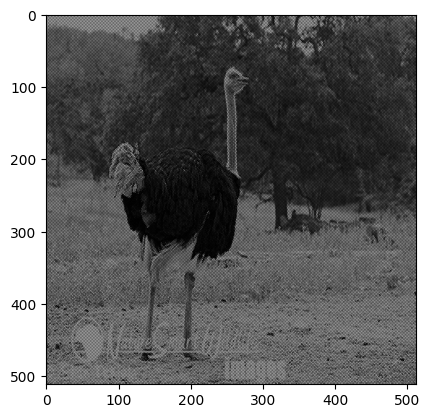

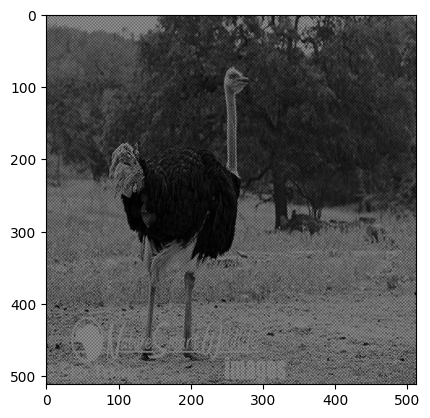

In [ ]:
imshow((cross[0][0]))
imshow((dot[0][0]))

In [ ]:
dataiter = iter(test_loader)


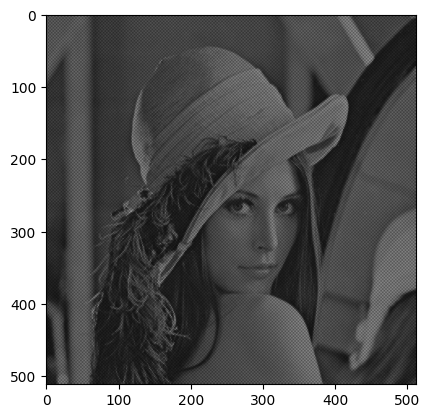

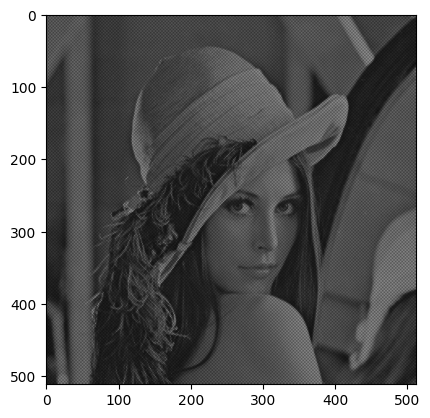

In [ ]:
cross1,dot1 = next(dataiter)
imshow(cross1[0][0])
imshow(dot1[0][0])

In [ ]:
model.eval()
out = model((cross1[0].float()).to(device))
#out = model((cross1[0][0]).to(device))

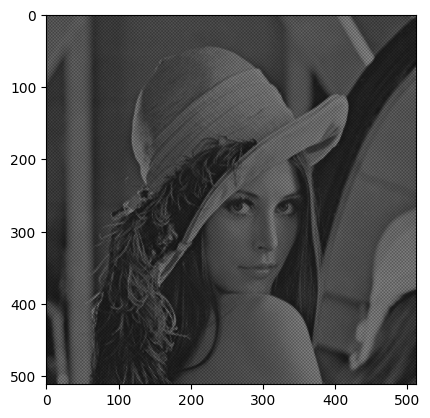

In [ ]:
imshow(out[0].detach().cpu())

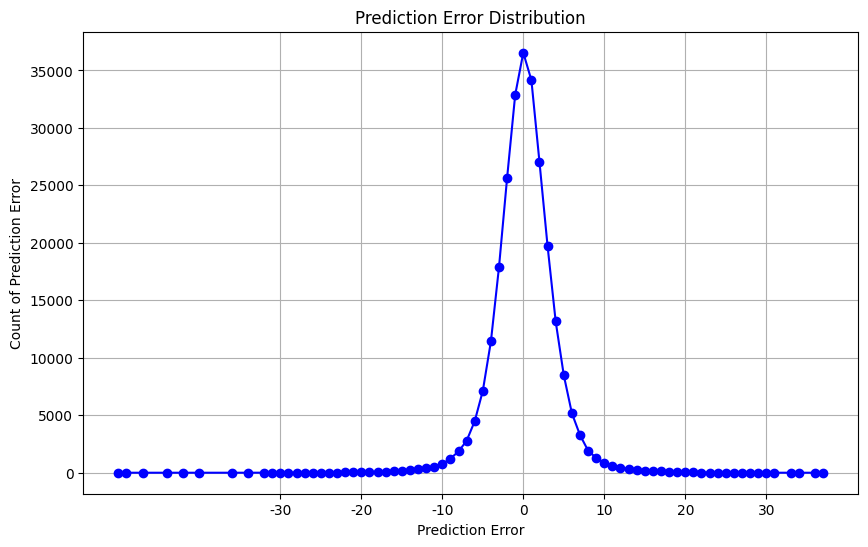

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


# Calculate the count of prediction errors for each value
unique_errors, error_counts = np.unique(rounded_result_Lena, return_counts=True)

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(unique_errors, error_counts, marker='o', linestyle='-', color='b')
plt.xlabel('Prediction Error')
plt.ylabel('Count of Prediction Error')
plt.title('Prediction Error Distribution')
plt.grid(True)

# Set custom x-axis ticks and labels
x_ticks = range(-30, 31, 10)
x_labels = [str(tick) for tick in x_ticks]
plt.xticks(x_ticks, x_labels)

plt.show()

In [ ]:
# msearr1 = []
model.eval()

for j,(inp,target) in  enumerate(test_loader):
#     print(j)
    #out = model((inp[0]).to(device))
    out = model((inp[0].float()).to(device))
    for i in range(batch):
#         print(out[i])
        try:
            a= npr(out[i].detach().cpu())
            b =npr(target[0][i])
#         print(a)
#     loss = criterion(out,target[0])
            msearr1.append(mse(a,b))
        except:
            continue



In [ ]:
# len(msearr1)

In [ ]:
# sum(msearr1)/63*4